# This is an example Jupyter Notebook for CLIP experiments
In this example single dog image is processed and classified.

In [1]:
import torch
import clip
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

Check for cuda for faster use

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Detected device: {device.upper()}")

Detected device: CPU


In [3]:
model, preprocess = clip.load("ViT-B/32", device=device)

image_path = Path.cwd().parent / "images" / "example" / "dog.png"
image = Image.open(image_path)

image_input = preprocess(image).unsqueeze(0).to(device) #type:ignore

100%|███████████████████████████████████████| 338M/338M [00:08<00:00, 41.5MiB/s]


In [4]:
labels = ["a diagram", "a dog", "a cat"]
text = clip.tokenize(labels).to(device)

with torch.no_grad():
    logits_per_image, _ = model(image_input, text)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

for label, prob in zip(labels, probs):
    print(f"- {label}: {prob * 100:.2f}%")

- a diagram: 0.53%
- a dog: 99.31%
- a cat: 0.15%


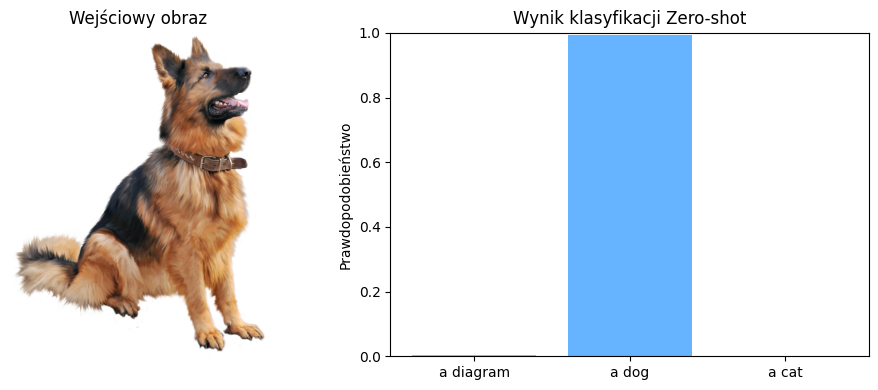

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.imshow(image)
ax1.set_title("Wejściowy obraz")
ax1.axis("off")

colors = ['#ff9999', '#66b3ff', '#99ff99']
ax2.bar(labels, probs, color=colors)
ax2.set_title("Wynik klasyfikacji Zero-shot")
ax2.set_ylabel("Prawdopodobieństwo")
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("test_output.png")

plt.show()

In [8]:
import random
from torchvision.datasets import FashionMNIST

[Ground Truth]: PULLOVER

--- CLIP Zero-Shot Top Probabilities ---
- t-shirt: 0.77%
- trouser: 0.56%
- pullover: 97.68%
- dress: 0.04%
- coat: 0.46%
- sandal: 0.01%
- shirt: 0.42%
- sneaker: 0.02%
- bag: 0.03%
- ankle boot: 0.01%


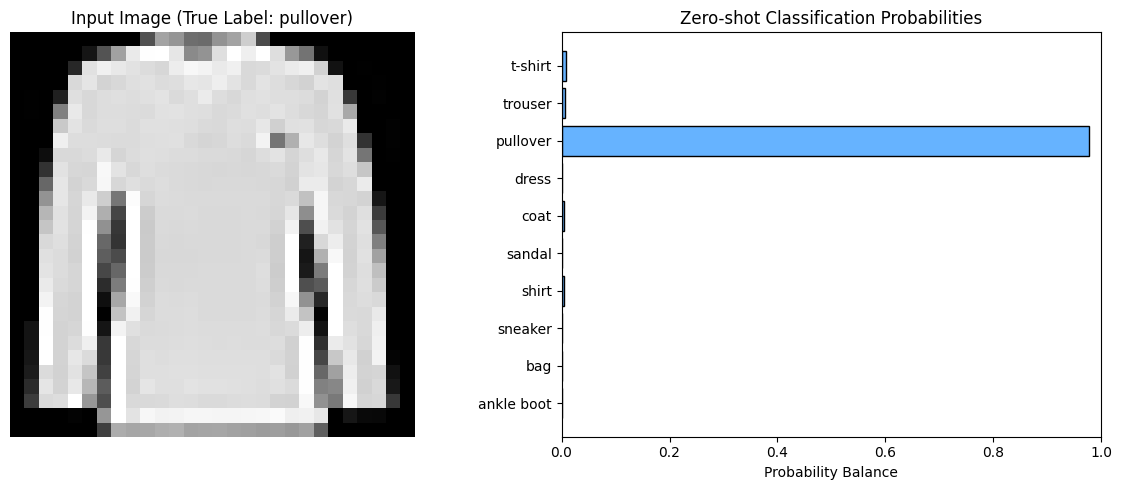

In [9]:
dataset = FashionMNIST(root="./data", train=False, download=True)

# 2. Set up clothing categories and target prompt templates
class_names = [
    "t-shirt", "trouser", "pullover", "dress", "coat", 
    "sandal", "shirt", "sneaker", "bag", "ankle boot"
]
labels = [f"a photo of a {name}" for name in class_names]

# 3. Select a random test image
idx = random.randint(0, len(dataset) - 1)
image, ground_truth_idx = dataset[idx]
correct_label = class_names[ground_truth_idx]

# 4. Format the image: Convert 1-channel grayscale to 3-channel RGB for CLIP
image_rgb = image.convert("RGB")
image_input = preprocess(image_rgb).unsqueeze(0).to(device)
text = clip.tokenize(labels).to(device)

# 5. Execute zero-shot inference (reusing your globally defined 'model')
with torch.no_grad():
    logits_per_image, _ = model(image_input, text)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()[0]

# 6. Output text evaluation
print(f"[Ground Truth]: {correct_label.upper()}\n")
print("--- CLIP Zero-Shot Top Probabilities ---")
for name, prob in zip(class_names, probs):
    print(f"- {name}: {prob * 100:.2f}%")
    
# 7. Generate notebook inline visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Grayscale display
ax1.imshow(image, cmap="gray")
ax1.set_title(f"Input Image (True Label: {correct_label})")
ax1.axis("off")

# Horizontal probability layout
y_pos = range(len(class_names))
ax2.barh(y_pos, probs, color='#66b3ff', edgecolor='black')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(class_names)
ax2.set_title("Zero-shot Classification Probabilities")
ax2.set_xlabel("Probability Balance")
ax2.set_xlim(0, 1)
ax2.invert_yaxis() 

plt.tight_layout()
plt.show()

Running batch evaluation across the full dataset...

================ STATISTICAL REPORT ================
              precision    recall  f1-score   support

     t-shirt       0.88      0.51      0.64      1000
     trouser       0.91      0.93      0.92      1000
    pullover       0.28      0.96      0.44      1000
       dress       0.75      0.59      0.66      1000
        coat       0.46      0.07      0.12      1000
      sandal       0.77      0.41      0.53      1000
       shirt       0.59      0.04      0.07      1000
     sneaker       0.67      0.95      0.79      1000
         bag       0.90      0.85      0.88      1000
  ankle boot       0.72      0.78      0.74      1000

    accuracy                           0.61     10000
   macro avg       0.69      0.61      0.58     10000
weighted avg       0.69      0.61      0.58     10000



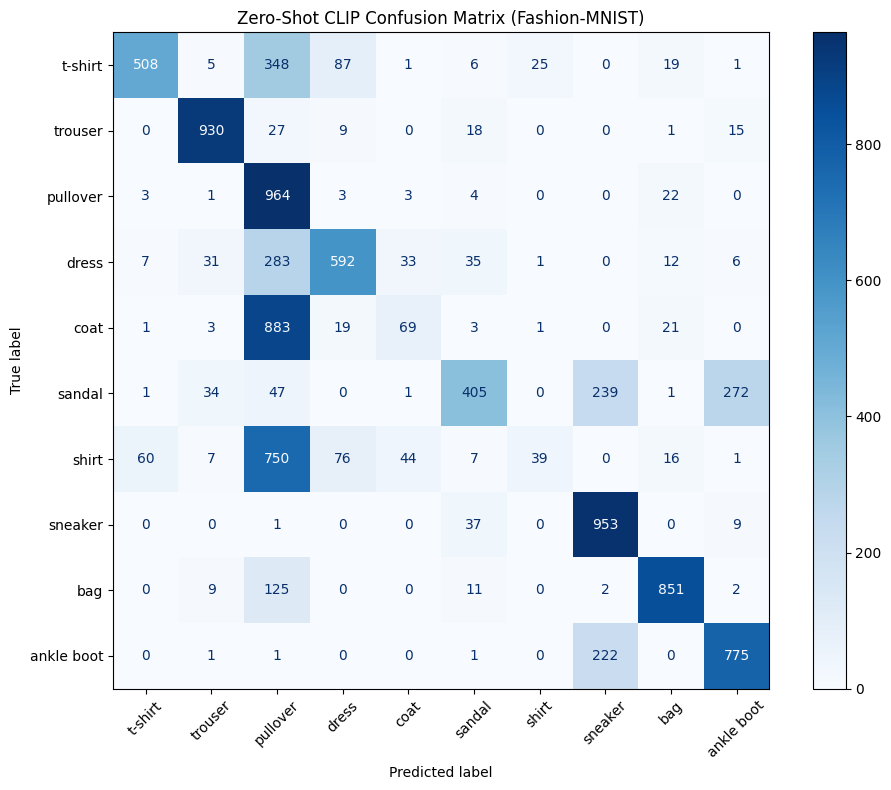

In [12]:
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Create an efficient DataLoader to batch the data
# (Reuses your globally downloaded 'dataset', 'preprocess', 'model', and 'device')
def collate_fn(batch):
    """Custom collate function to preprocess images on the fly into a single tensor."""
    images = [preprocess(img[0].convert("RGB")) for img in batch]
    targets = [img[1] for img in batch]
    return torch.stack(images), torch.tensor(targets)

test_loader = DataLoader(
    dataset, 
    batch_size=64, 
    shuffle=False, 
    collate_fn=collate_fn, 
    num_workers=0
)

# 2. Tokenize text prompts once (outside the loop to save compute)
class_names = [
    "t-shirt", "trouser", "pullover", "dress", "coat", 
    "sandal", "shirt", "sneaker", "bag", "ankle boot"
]
labels = [f"a photo of a {name}" for name in class_names]
text_inputs = clip.tokenize(labels).to(device)

all_preds = []
all_targets = []

print("Running batch evaluation across the full dataset...")

# 3. Evaluation loop over all 10,000 images
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        
        # Calculate similarity logits
        logits_per_image, _ = model(images, text_inputs)
        
        # Find the index of the maximum probability for each image
        preds = logits_per_image.argmax(dim=-1).cpu().numpy()
        
        all_preds.extend(preds)
        all_targets.extend(targets.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# 4. Generate and Print the Statistical Metrics
print("\n================ STATISTICAL REPORT ================")
print(classification_report(all_targets, all_preds, target_names=class_names))

# 5. Generate and Plot the Confusion Matrix for your Seminar Slide
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation=45)
ax.set_title("Zero-Shot CLIP Confusion Matrix (Fashion-MNIST)")
plt.tight_layout()
plt.savefig("fashion_mnist_confusion_matrix.png")
plt.show()

In [13]:
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Standard classical transformations (Normalizing 1-channel grayscale to [-1, 1])
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load training split to train the network from scratch
train_dataset = FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = FashionMNIST(root="./data", train=False, download=True, transform=transform)

# Reusing num_workers=0 to maintain notebook process stability
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

# 2. Define a standard Classical CNN architecture
class ClassicalCNN(nn.Module):
    def __init__(self):
        super(ClassicalCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# Initialize and mount model (reusing your global 'device' token)
classical_model = ClassicalCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classical_model.parameters(), lr=0.001)

# 3. Training execution block
print("Training classical CNN model from scratch...")
classical_model.train()
for epoch in range(3):
    running_loss = 0.0
    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = classical_model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    print(f"Epoch {epoch+1}/3 - Loss: {running_loss/len(train_loader):.4f}")

print("Training complete!")

Training classical CNN model from scratch...
Epoch 1/3 - Loss: 0.4320
Epoch 2/3 - Loss: 0.2787
Epoch 3/3 - Loss: 0.2322
Training complete!


Running batch evaluation for Classical NN...

================ CLASSICAL NN REPORT ================
              precision    recall  f1-score   support

     t-shirt       0.83      0.90      0.86      1000
     trouser       0.99      0.98      0.99      1000
    pullover       0.82      0.90      0.86      1000
       dress       0.87      0.94      0.90      1000
        coat       0.89      0.80      0.84      1000
      sandal       0.99      0.94      0.97      1000
       shirt       0.81      0.68      0.74      1000
     sneaker       0.93      0.97      0.95      1000
         bag       0.98      0.98      0.98      1000
  ankle boot       0.96      0.97      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.90     10000
weighted avg       0.91      0.91      0.90     10000



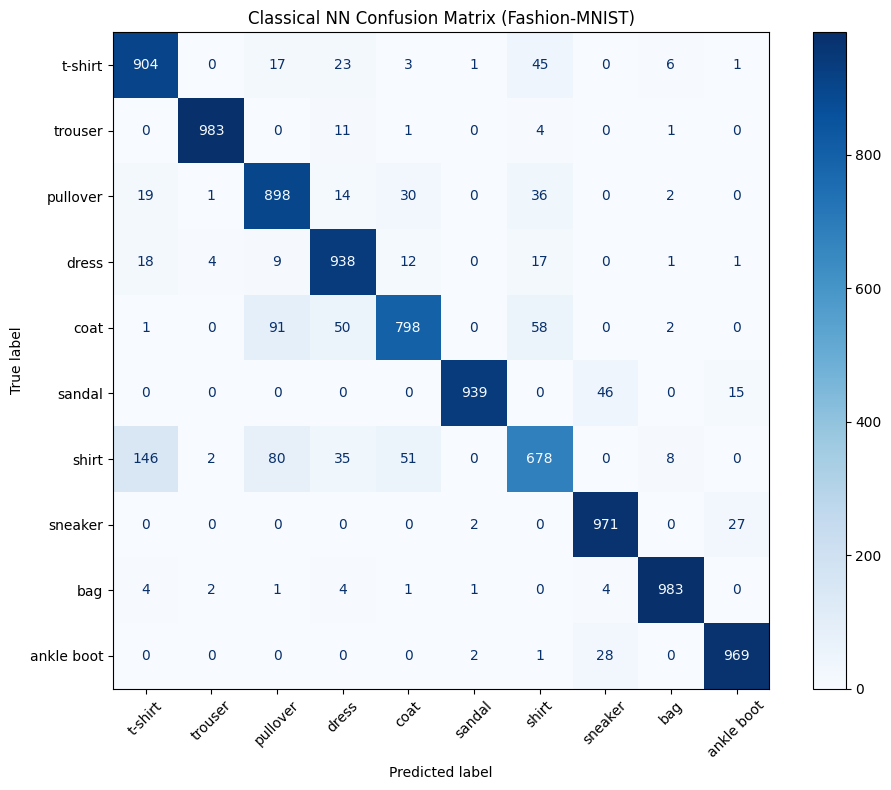

In [14]:
# 4. Evaluate the Classical CNN on the test set
classical_model.eval()
nn_preds = []
nn_targets = []

print("Running batch evaluation for Classical NN...")
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        outputs = classical_model(images)
        preds = outputs.argmax(dim=-1).cpu().numpy()
        
        nn_preds.extend(preds)
        nn_targets.extend(targets.numpy())

nn_preds = np.array(nn_preds)
nn_targets = np.array(nn_targets)

# 5. Class categories mapping
class_names = [
    "t-shirt", "trouser", "pullover", "dress", "coat", 
    "sandal", "shirt", "sneaker", "bag", "ankle boot"
]

# Print the matching text report structure
print("\n================ CLASSICAL NN REPORT ================")
print(classification_report(nn_targets, nn_preds, target_names=class_names))

# 6. Plot the exact same Confusion Matrix styling for a true layout match
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(nn_targets, nn_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Replicating styling variables: Blues scale, absolute integer tracking, 45-degree labels
disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation=45)
ax.set_title("Classical NN Confusion Matrix (Fashion-MNIST)")
plt.tight_layout()
plt.savefig("classical_nn_confusion_matrix.png")
plt.show()